# 鸢尾花数据K-Means聚类实验




### 1. K-Means 简介与数据集选择理由

#### 什么是 K-Means

K-Means 是经典的**无监督聚类算法**。它通过不断迭代，将样本分配到最近的簇中心，并更新簇中心，使簇内样本尽量紧密。

**核心原理：**
1. **初始化**：随机选择 K 个样本作为初始簇中心
2. **分配**：将每个样本分配到距离最近的簇中心
3. **更新**：重新计算每个簇的中心（簇内所有样本的均值）
4. **迭代**：重复"分配-更新"步骤，直到簇中心不再变化或达到最大迭代次数

**算法特点：**
- 简单高效，易于理解和实现
- 适合处理大规模数据
- 结果依赖初始中心的选择（可能陷入局部最优）
- 假设簇是球形的，对异常值敏感

#### 什么时候使用 K-Means

**适用场景：**
1. **数据探索**：想了解数据的自然分组结构
2. **客户细分**：根据消费行为将客户分组
3. **图像压缩**：将相似颜色聚成一类，减少色彩数量
4. **文档分类**：将相似主题的文档聚在一起
5. **异常检测**：离簇中心较远的点可能是异常值

**不适合场景：**
- 簇的形状不规则（非球形）
- 簇的密度差异很大
- 数据维度很高且特征间相关性强
- 簇的大小差异很大

#### 如何选择 K 值

选择合适的 K 值是 K-Means 最关键的步骤。常用方法：

**1. 手肘法（Elbow Method）**
- **原理**：随着 K 增大，簇内距离平方和（惯性）会下降
- **选择**：在曲线出现"拐点"（像手肘一样弯曲）的位置选择 K
- **优点**：直观易懂
- **缺点**：有时拐点不明显

**2. 轮廓系数法（Silhouette Score）**
- **原理**：衡量样本与所属簇的相似度，以及与其他簇的差异度
- **取值范围**：[-1, 1]，值越大越好
- **选择**：轮廓系数最大的 K 值
- **优点**：综合考虑簇内紧密度和簇间分离度

**3. 领域知识**
- 根据实际业务需求确定分组数量
- 例如：客户细分时可能根据营销策略预设分组数

**本实验中：**
我们将使用**手肘法**和**轮廓系数法**两种方法来确定最佳 K 值。

#### 为什么使用鸢尾花数据集
1. 数据量适中，便于快速实验与理解。
2. 特征清晰，适合做可视化与解释。
3. 类别分布有区分度，便于观察聚类效果。
4. Scikit-learn 内置数据集，无需下载。
5. 本实验聚类时不使用真实标签，仅用于"参考评估"和对比可视化。

#### 本实验目标
1. 完成 K-Means 聚类并选择合适的 K。
2. 了解标准化对聚类的影响。
3. 用 PCA 将 4 维特征降到 2 维进行可视化。

---

### 2. 数据集说明

本实验使用鸢尾花公开数据集（Iris），包含150个样本，4个数值特征（萼片长、萼片宽、花瓣长、花瓣宽），3个分类标签。
数据来源：Scikit-learn 内置数据集（`sklearn.datasets.load_iris()`）。
本实验聚类时不使用真实标签，仅作为对比参考。

---

### 3. 实验环境与依赖

#### 系统环境需求
- Python 版本：3.10+
- Jupyter：Jupyter Notebook 或 JupyterLab
- 操作系统：Windows / Linux / macOS

#### 必需库及版本
| 库名 | 用途 | 最小版本 |
|------|------|---------|
| numpy | 数值计算 | 1.20+ |
| pandas | 数据处理 | 1.1+ |
| matplotlib | 绘图 | 3.3+ |
| seaborn | 统计绘图 | 0.11+ |
| scikit-learn | 机器学习 | 0.24+ |

#### 快速安装
```bash
# 创建虚拟环境（推荐）
conda create -n iris_cluster_env python=3.10

# 激活环境
conda activate iris_cluster_env

# 安装依赖
pip install numpy pandas matplotlib seaborn scikit-learn jupyter
```

### 4. 导入必要的库

In [1]:
# ============================================================================
# 导入必要的库
# ============================================================================

# 数值计算
import numpy as np  # 数组与矩阵计算

# 数据处理
import pandas as pd  # 表格型数据处理

# 可视化
import matplotlib.pyplot as plt  # 基础绘图
import seaborn as sns  # 统计绘图（更美观）

# 机器学习 - 数据集与预处理
from sklearn.datasets import load_iris  # 加载鸢尾花数据集
from sklearn.preprocessing import StandardScaler  # 特征标准化

# 机器学习 - 聚类算法
from sklearn.cluster import KMeans  # K-Means 聚类

# 机器学习 - 评价指标（无监督）
from sklearn.metrics import silhouette_score, adjusted_rand_score  # 轮廓系数、ARI（仅做参考）

# 机器学习 - 降维与可视化
from sklearn.decomposition import PCA  # PCA 降维

# 其他
import warnings  # 忽略警告信息

# ============================================================================
# 配置
# ============================================================================

# 让 matplotlib 支持中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']  # 中文字体
plt.rcParams['axes.unicode_minus'] = False  # 正确显示负号

# 忽略一些不影响学习的警告
warnings.filterwarnings('ignore')

# 设置随机种子，保证每次运行结果一致
np.random.seed(42)

### 5. 读取数据与基本查看

说明：该数据集由 Scikit-learn 内置提供，无需下载。

In [2]:
# ============================================================================
# 加载鸢尾花数据集
# ============================================================================

iris = load_iris()  # 加载数据

# 特征名称
feature_names = iris.feature_names

# 将特征和标签组成 DataFrame，便于观察
df = pd.DataFrame(iris.data, columns=feature_names)
df['label'] = iris.target  # 真实标签（仅用于参考评估）
df['species'] = df['label'].map({0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'})

# 查看数据基本信息
print('数据集形状:', df.shape)
display(df.head())
display(df.describe())

数据集形状: (150, 6)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),label,species
0,5.1,3.5,1.4,0.2,0,Setosa
1,4.9,3.0,1.4,0.2,0,Setosa
2,4.7,3.2,1.3,0.2,0,Setosa
3,4.6,3.1,1.5,0.2,0,Setosa
4,5.0,3.6,1.4,0.2,0,Setosa


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),label
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


### 6. 选择数值特征并做基础探索

说明：层次聚类基于距离计算，先选择数值型特征进行可视化。

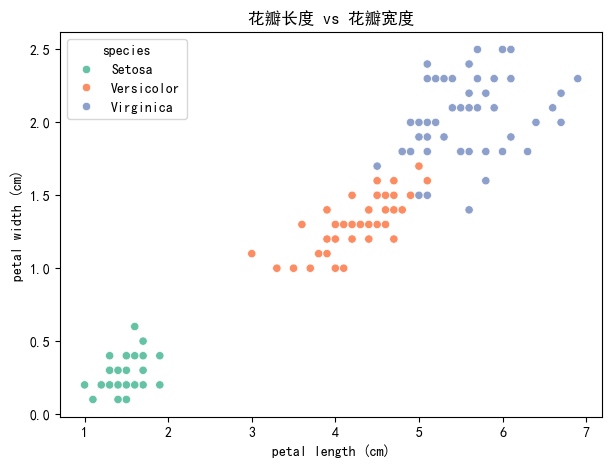

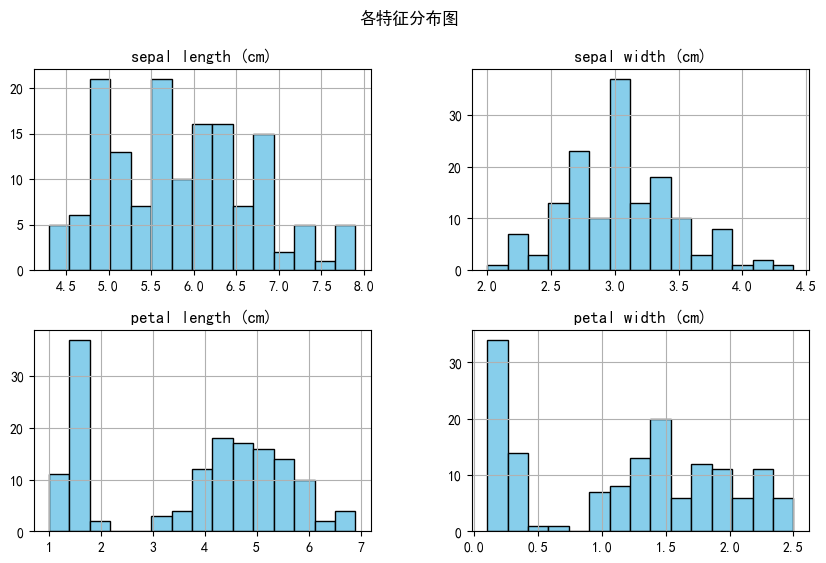

In [3]:
# ============================================================================
# 1) 观察不同特征之间的关系（散点图）
# ============================================================================

plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df,
    x='petal length (cm)',
    y='petal width (cm)',
    hue='species',
    palette='Set2'
)
plt.title('花瓣长度 vs 花瓣宽度')
plt.show()

# ============================================================================
# 2) 查看每个特征的分布（直方图 + KDE）
# ============================================================================

df[feature_names].hist(figsize=(10, 6), bins=15, color='skyblue', edgecolor='black')
plt.suptitle('各特征分布图')
plt.show()

### 7. 特征标准化说明

K-Means 使用**距离**来度量样本的相似性，如果不同特征量纲差异很大，距离会被大数值特征主导。因此在聚类前先做标准化，使每个特征在同一尺度上，结果更稳定、更公平。

### 4. 特征标准化

In [4]:
# ============================================================================
# 特征标准化：让每个特征在相同尺度上，有助于聚类效果
# ============================================================================

X = df[feature_names].values  # 只取特征

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('标准化后均值(约为0):', X_scaled.mean(axis=0))
print('标准化后标准差(约为1):', X_scaled.std(axis=0))

标准化后均值(约为0): [-1.69031455e-15 -1.84297022e-15 -1.69864123e-15 -1.40924309e-15]
标准化后标准差(约为1): [1. 1. 1. 1.]


### 9. K-Means 的K值选择（肘部法 + 轮廓系数）

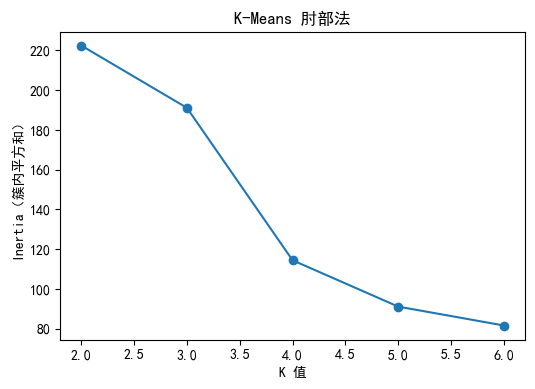

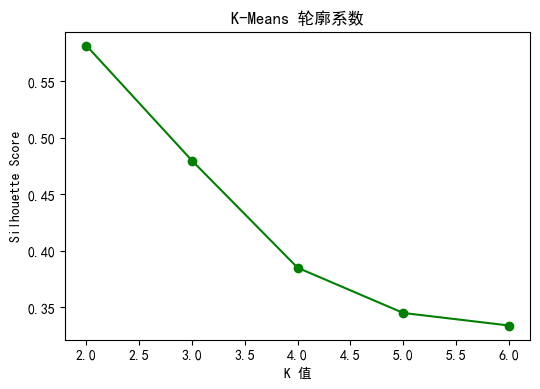

In [5]:
# ============================================================================
# K-Means 需要指定 K（簇的数量）。常见做法：
# - 肘部法：看惯性(inertia)下降的拐点
# - 轮廓系数：越高越好（取 2~6 试试）
# ============================================================================

ks = range(2, 7)
inertias = []
sil_scores = []

for k in ks:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

# 绘制肘部法曲线
plt.figure(figsize=(6, 4))
plt.plot(ks, inertias, marker='o')
plt.title('K-Means 肘部法')
plt.xlabel('K 值')
plt.ylabel('Inertia（簇内平方和）')
plt.show()
# 绘制轮廓系数
plt.figure(figsize=(6, 4))
plt.plot(ks, sil_scores, marker='o', color='green')
plt.title('K-Means 轮廓系数')
plt.xlabel('K 值')
plt.ylabel('Silhouette Score')
plt.show()

#### 如何阅读这两张图表

**图表1：肘部法曲线（Inertia）**

- **横轴**：K值（簇的数量）
- **纵轴**：Inertia（簇内平方和），表示所有样本到其所属簇中心的距离平方和
- **如何判断**：
  - Inertia越小，表示簇内样本越紧密
  - 随着K增大，Inertia一定会下降（簇越多，每个簇越小，自然越紧密）
  - 找**拐点**（曲线明显转折的地方）：拐点之前下降快，拐点之后下降变缓
  - 拐点对应的K值通常是较好的选择

**图表2：轮廓系数曲线（Silhouette Score）**

- **横轴**：K值（簇的数量）
- **纵轴**：轮廓系数，范围[-1, 1]
- **如何判断**：
  - 轮廓系数越接近1越好（簇内紧密、簇间分离）
  - 轮廓系数接近0表示簇之间有重叠
  - 轮廓系数为负表示样本可能被分到了错误的簇
  - 找**峰值**（最高点）：对应的K值是推荐的簇数量



### 10. 训练 K-Means 并查看聚类结果

In [6]:
# ============================================================================
# 假设 K=3（因为我们知道鸢尾花有三类）
# ============================================================================

kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
kmeans_labels = kmeans.fit_predict(X_scaled)

df['kmeans_cluster'] = kmeans_labels

print('K-Means 每个簇的样本数：')
print(df['kmeans_cluster'].value_counts())

# 轮廓系数（无监督指标）
print('K-Means 轮廓系数:', silhouette_score(X_scaled, kmeans_labels))

# ARI：与真实标签对比（仅作为参考，不影响无监督训练）
print('K-Means ARI(参考):', adjusted_rand_score(df['label'], kmeans_labels))

K-Means 每个簇的样本数：
kmeans_cluster
0    96
1    33
2    21
Name: count, dtype: int64
K-Means 轮廓系数: 0.4798814508199817
K-Means ARI(参考): 0.432804702527474


### 11. PCA 降维与结果可视化

#### 什么是 PCA（主成分分析）

**PCA（Principal Component Analysis，主成分分析）** 是一种常用的降维技术。

**核心思想：**
- 将高维数据投影到低维空间，同时**保留最多的信息**
- 找到数据中最重要的方向（主成分），用更少的维度来表示数据

**为什么需要降维：**
1. **可视化**：人眼只能看到2D或3D，而数据可能有几十甚至几百个特征
2. **去除冗余**：很多特征之间存在相关性，可以合并成更少的特征
3. **加速计算**：维度降低后，算法运行更快
4. **避免维度灾难**：高维空间中数据会变得稀疏，影响算法效果

**本实验中：**
- 鸢尾花数据有 **4 个特征**（萼片长宽、花瓣长宽）
- 用 PCA 降到 **2 个主成分**（PC1、PC2）
- 这样可以在**二维平面**上画图，直观观察聚类效果

**注意：**
- PCA 降维后的 PC1、PC2 不再是原始特征，而是原始特征的**线性组合**
- PC1 是数据方差最大的方向，PC2 是次大的方向（且与 PC1 垂直）
- 降维会损失一些信息，但通常前几个主成分能保留 80%-95% 的信息

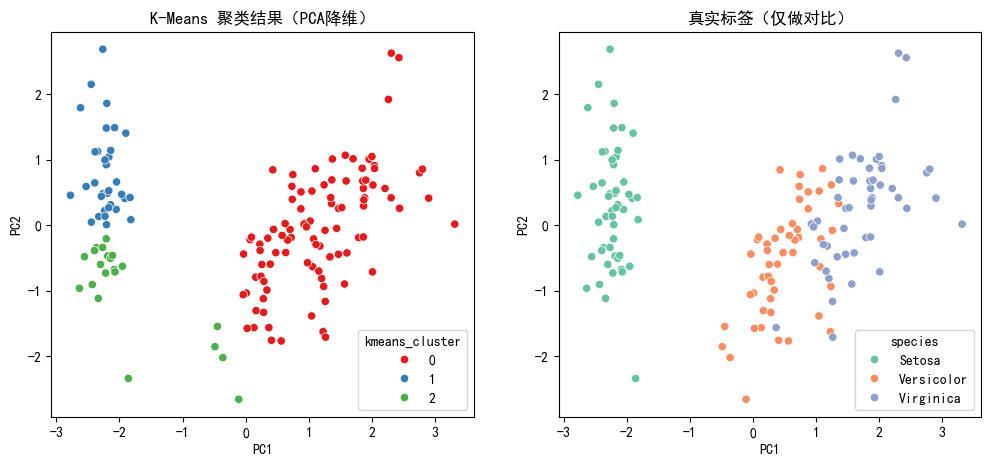

In [7]:
# ============================================================================
# PCA 将 4 维特征降到 2 维，方便画图
# ============================================================================

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['kmeans_cluster'] = kmeans_labels
pca_df['species'] = df['species']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='kmeans_cluster', palette='Set1', ax=axes[0])
axes[0].set_title('K-Means 聚类结果（PCA降维）')

sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='species', palette='Set2', ax=axes[1])
axes[1].set_title('真实标签（仅做对比）')

plt.show()

### 8. 小结与思考

- **K-Means**：简单高效，但需要指定K值。
- **PCA 可视化**：把 4 维降到 2 维，便于观察聚类结果。

#### 思考题：
1. 如果只用“花瓣长度+花瓣宽度”两个特征，聚类效果会怎样？
2. K 值选得太大或太小，会对聚类结果造成什么影响？
3. PCA 是“为了可视化”还是“为了提高聚类效果”？为什么？

---

